This cell is importing the required libraries.
<br>We are making Directories for saving models and figures, and helper functions are defined to track experiment progress.

In [1]:
# imports and basic setup
import os, time, json, joblib, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psutil

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, KFold, RandomizedSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Models
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

RANDOM_SEED = 42
SAMPLE_MODE = True
SAMPLE_FRAC = 0.05
GROUP_K = 5
N_JOBS = max(1, (psutil.cpu_count(logical=False) or 1) - 0)


OUT_DIR = Path("models_week5_7"); OUT_DIR.mkdir(exist_ok=True, parents=True)
FIG_DIR = Path("figures_week5_7"); FIG_DIR.mkdir(exist_ok=True, parents=True)

# Feature files (prefer fixed parquet)
FEAT_FP_FIXED = Path("data_processed/features_cycle_with_core_fixed.parquet")
FEAT_FP_STD   = Path("data_processed/features_cycle_with_core.parquet")
FEAT_FP = FEAT_FP_FIXED if FEAT_FP_FIXED.exists() else FEAT_FP_STD

PROCESSED_PREP_FP = OUT_DIR / "preprocessed_train_test.joblib"
PROGRESS_FP = OUT_DIR / "progress_week5_7.json"

def load_progress():
    if PROGRESS_FP.exists():
        return json.loads(PROGRESS_FP.read_text())
    else:
        p = {"preprocessed": False, "baseline_done": [], "tuned_done": [], "explain_done": False}
        PROGRESS_FP.write_text(json.dumps(p))
        return p

def save_progress(progress):
    PROGRESS_FP.write_text(json.dumps(progress))

## Visualization and Helper Functions

Here we making the plotting environment and defining helper functions.

- Setting **Seaborn and Matplotlib styles** for plots.
- Defining a function to find  **RMSE (Root Mean Squared Error)**.


In [2]:
# Cell 2 - plotting and small helpers
import math
from pathlib import Path

sns.set(style="whitegrid")
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 12

def rmse(y_true, y_pred):
    return math.sqrt(mean_squared_error(y_true, y_pred))

def save_fig(fig, fp, dpi=300):
    fp = Path(fp); fp.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(fp, dpi=dpi, bbox_inches='tight')
    plt.close(fig)

def parity_plot(y_true, y_pred, title, out_fp=None):
    fig, ax = plt.subplots(figsize=(6,5))
    ax.scatter(y_true, y_pred, s=10, alpha=0.6, c='tab:blue')
    mn = min(np.nanmin(y_true), np.nanmin(y_pred)); mx = max(np.nanmax(y_true), np.nanmax(y_pred))
    ax.plot([mn,mx],[mn,mx],'--k', linewidth=1)
    ax.set_xlabel("True"); ax.set_ylabel("Pred"); ax.set_title(title)
    if out_fp: save_fig(fig, out_fp)

def resid_plot(y_true, y_pred, title, out_fp=None):
    res = np.array(y_pred) - np.array(y_true)
    fig, ax = plt.subplots(figsize=(6,3))
    ax.hist(res, bins=60, alpha=0.9)
    ax.set_title(title)
    if out_fp: save_fig(fig, out_fp)

## Data Loading and Train-Test Split

- Reads the **feature file (parquet format)**.
- Applies a **Zero → NaN conversion heuristic** to handle suspicious zero values in numeric columns.
- Using **sample mode** to optionally work with a small subset of cells for faster experimentation.
- Splitting the dataset into **training and testing sets** using **GroupShuffleSplit** based on cell_id to avoid data leakage between cells.
- Saving the processed train and test datasets as a checkpoint using joblib so preprocessing does not need to be repeated in future runs.

In [3]:
# Cell 3 - load features, apply zero->NaN, sample, and group split
progress = load_progress()
if progress.get("preprocessed", False) and PROCESSED_PREP_FP.exists():
    print("Loading preprocessing checkpoint:", PROCESSED_PREP_FP)
    prep = joblib.load(PROCESSED_PREP_FP)
    feat_df = prep['feat_df']
    train_df = prep['train_df_raw']
    test_df  = prep['test_df_raw']
    print("Loaded checkpoint. Train rows:", len(train_df), "Test rows:", len(test_df))
else:
    feat_df = pd.read_parquet(FEAT_FP)
    print("Loaded features:", feat_df.shape)

    # Zero -> NaN conversion (conservative)
    ZERO_TO_NA = True
    if ZERO_TO_NA:
        numeric_cols_all = feat_df.select_dtypes(include=[np.number]).columns.tolist()
        zero_to_na_cols = []
        for c in numeric_cols_all:
            try:
                z_frac = (feat_df[c] == 0).mean()
                if (z_frac > 0) and (z_frac < 0.5) and (feat_df[c].mean() > 0):
                    zero_to_na_cols.append(c)
            except Exception:
                continue
        if zero_to_na_cols:
            print("Zero->NaN applied to columns:", zero_to_na_cols)
            feat_df[zero_to_na_cols] = feat_df[zero_to_na_cols].replace(0, np.nan)
        else:
            print("Zero->NaN: no columns matched heuristic.")

    # sampling for quick runs
    df_work = feat_df
    if SAMPLE_MODE:
        unique_cells = df_work['cell_id'].unique()
        sampled_cells = np.random.choice(unique_cells, max(1,int(len(unique_cells)*SAMPLE_FRAC)), replace=False)
        df_work = df_work[df_work['cell_id'].isin(sampled_cells)].reset_index(drop=True)
        print("Sample mode: rows:", len(df_work))

    # grouped holdout split
    gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_SEED)
    groups = df_work['cell_id'].values
    train_idx, test_idx = next(gss.split(df_work, groups=groups))
    train_df = df_work.iloc[train_idx].reset_index(drop=True)
    test_df  = df_work.iloc[test_idx].reset_index(drop=True)
    print("Train rows:", len(train_df), "Test rows:", len(test_df))

    # checkpoint preprocessing
    prep = {'feat_df': feat_df, 'train_df_raw': train_df, 'test_df_raw': test_df}
    joblib.dump(prep, PROCESSED_PREP_FP)
    print("Saved preprocessing checkpoint:", PROCESSED_PREP_FP)
    progress['preprocessed'] = True
    save_progress(progress)

Loading preprocessing checkpoint: models_week5_7/preprocessed_train_test.joblib
Loaded checkpoint. Train rows: 1837 Test rows: 99


## Model Training

The pipeline performs the following steps:
- Loading the feature dataset and filters rows with valid target values.
- Optionally samples the dataset for faster experimentation.
- Selects numeric features and removes constant or non-feature columns.
- Splits the data into **training and testing sets using GroupShuffleSplit** based on `cell_id` to avoid data leakage.

The function then:
- Applies **preprocessing** (median imputation and standard scaling).
- Trains baseline models including **KNN, SVR, Linear Regression, and Decision Tree**.
- Evaluates models using **RMSE, MAE, and R²** metrics.
- Computes **Permutation Importance** for the best-performing model to understand feature impact.
- Performs **Cross-Validation** and **Hyperparameter Tuning using RandomizedSearchCV**.

The function returns the model performance results for further analysis.

In [4]:
#Cell 4
from datetime import datetime
from tqdm import tqdm
from sklearn.inspection import permutation_importance

def run_training_pipeline(
        target_col,
        suffix='core',
        sample_mode='none',
        sample_frac=0.2,
        do_tuning=True,
        tuning_n_iter=12):

    def now():
        return datetime.now().strftime("%H:%M:%S")

    print(f"\n[{now()}] === PIPELINE START: {suffix} (target={target_col}) ===")
    feat_df_all = pd.read_parquet(FEAT_FP)
    df = feat_df_all[feat_df_all[target_col].notna()].reset_index(drop=True)
    print(f"[{now()}] Total rows with target:", len(df))
    # df = feat_df_all[feat_df_all[target_col].notna()].reset_index(drop=True)
    print(f"[{now()}] Total rows with target:", len(df))

    if sample_mode == "frac":
        df = df.sample(frac=sample_frac, random_state=RANDOM_SEED)
    elif sample_mode == "n":
        df = df.sample(n=int(sample_frac), random_state=RANDOM_SEED)

    print(f"[{now()}] Sampled df rows:", len(df))

    non_features = {'cell_id','cycle','dataset','chemistry'}

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols.remove(target_col)

    features_list = [c for c in numeric_cols if c not in non_features]

    nunique = df[features_list].nunique()
    features_list = nunique[nunique > 1].index.tolist()

    print(f"[{now()}] Number of features used (non-constant):", len(features_list))

    df = df[features_list + [target_col,'cell_id']]

    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_SEED)

    train_idx, test_idx = next(gss.split(df, groups=df['cell_id']))

    train_df_loc = df.iloc[train_idx]
    test_df_loc = df.iloc[test_idx]

    X_train = train_df_loc[features_list]
    y_train = train_df_loc[target_col]

    X_test = test_df_loc[features_list]
    y_test = test_df_loc[target_col]

    print(f"[{now()}] X_train shape:", X_train.shape, ", X_test shape:", X_test.shape)

    # preprocessing
    preproc = make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler()
    )

    X_train_p = preproc.fit_transform(X_train)
    X_test_p = preproc.transform(X_test)

    print(f"[{now()}] Preprocessing saved")

    # ==========================
    # MODEL DEFINITIONS
    # ==========================

    models = {}

    models['knn'] = KNeighborsRegressor(
        n_neighbors=5
    )

    models['svr'] = SVR(
        kernel='rbf',
        C=10,
        epsilon=0.1
    )

    models['lr'] = LinearRegression()

    models['dt'] = DecisionTreeRegressor(
        max_depth=10,
        random_state=RANDOM_SEED
    )

    results = {}

    # ==========================
    # BASELINE TRAINING
    # ==========================

    for name, model in models.items():

        print(f"[{now()}] Training baseline:", name)

        start = time.time()

        model.fit(X_train_p, y_train)

        preds = model.predict(X_test_p)

        rmse = np.sqrt(mean_squared_error(y_test, preds))
        mae = mean_absolute_error(y_test, preds)
        r2 = r2_score(y_test, preds)

        end = time.time()

        results[name] = {
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2,
            "y_preds":preds,
            "y_test":y_test.values
        }

        print(f"[{now()}] {name} baseline done, RMSE={rmse:.4f}, Time={end-start:.1f}s")

    # ==========================
    # PERMUTATION IMPORTANCE
    # ==========================

    best_model_name = min(results, key=lambda k: results[k]["RMSE"])
    best_model = models[best_model_name]

    print(f"[{now()}] Calculating permutation importance for", best_model_name)

    perm = permutation_importance(
        best_model,
        X_test_p,
        y_test,
        n_repeats=10,
        random_state=RANDOM_SEED
    )

    # ==========================
    # SAFE CV SPLIT
    # ==========================

    groups = train_df_loc['cell_id'].values
    unique_groups = np.unique(groups)

# Choose CV depending on number of groups
    
    if len(unique_groups) >= 3:
        CV = GroupKFold(n_splits=3)
        cv_iterator = list(CV.split(X_train_p, y_train, groups))
    elif len(unique_groups) == 2:
        CV = GroupKFold(n_splits=2)
        cv_iterator = list(CV.split(X_train_p, y_train, groups))
    else:
        print("Only one cell_id group detected → using KFold fallback")
        CV = KFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)
        cv_iterator = list(CV.split(X_train_p, y_train))
    # ==========================
    # TUNING
    # ==========================

    if do_tuning:

        print(f"[{now()}] Starting tuning with progress bars (n_iter={tuning_n_iter})")

        param_spaces = {

            "knn": {
                "n_neighbors": [3,5,7,9,11]
            },

            "svr": {
                "C":[1,5,10,20],
                "epsilon":[0.01,0.1,0.2]
            },

            "lr": {},

            "dt": {
                "max_depth":[5,10,15,20]
            }
        }

        for name, model in models.items():

            space = param_spaces[name]

            if len(space) == 0:
                continue

            print(f"[{now()}] Tuning {name}: {tuning_n_iter*2} fits (approx)")

            best_score = np.inf
            best_params = None

            for iteration in tqdm(range(min(tuning_n_iter,50)), desc=f"Tuning {name}", unit="iter"):
                
                rs = RandomizedSearchCV(
                    model,
                    param_distributions=space,
                    n_iter=1,
                    scoring='neg_root_mean_squared_error',
                    cv=3,
                    n_jobs=N_JOBS,
                    random_state=RANDOM_SEED,
                    verbose=0,
                    error_score='raise'
                )

                rs.fit(X_train_p, y_train)

                score = -rs.best_score_

                if score < best_score:
                    best_score = score
                    best_params = rs.best_params_

            print(f"[{now()}] Best params for {name}:", best_params)

    print(f"[{now()}] === PIPELINE END ===")

    return results

## Running the Core Temperature Prediction Pipeline

This cell runs the machine learning pipeline for predicting **core battery temperature**.

- First, the code checks which **core temperature target variable** is available in the dataset.
- It selects one of the following targets:
  - `core_mean_sim`
  - `core_peak_sim`
  - `core_temp_est_scalar`

After selecting the available target, the **training pipeline function** is executed with:
- Sampling settings for faster experimentation
- Baseline model training
- Cross-validation
- Hyperparameter tuning

The results of the trained models are stored in `core_results` for further analysis and evaluation.

In [5]:
# Cell 5 - RUN core temperature pipeline
feat_preview = pd.read_parquet(FEAT_FP)
if 'core_mean_sim' in feat_preview.columns:
    core_target = 'core_mean_sim'
elif 'core_peak_sim' in feat_preview.columns:
    core_target = 'core_peak_sim'
elif 'core_temp_est_scalar' in feat_preview.columns:
    core_target = 'core_temp_est_scalar'
else:
    raise KeyError("No core target found in features file.")

print("Selected core target:", core_target)
core_results = run_training_pipeline(target_col=core_target, suffix='core', sample_mode=SAMPLE_MODE, sample_frac=SAMPLE_FRAC, do_tuning=True, tuning_n_iter=12)

Selected core target: core_mean_sim

[11:34:33] === PIPELINE START: core (target=core_mean_sim) ===
[11:34:33] Total rows with target: 56419
[11:34:33] Total rows with target: 56419
[11:34:33] Sampled df rows: 56419
[11:34:33] Number of features used (non-constant): 39


[11:34:33] X_train shape: (44928, 39) , X_test shape: (11491, 39)
[11:34:33] Preprocessing saved
[11:34:33] Training baseline: knn
[11:34:36] knn baseline done, RMSE=0.1644, Time=2.5s
[11:34:36] Training baseline: svr
[11:34:41] svr baseline done, RMSE=0.2445, Time=5.3s
[11:34:41] Training baseline: lr
[11:34:41] lr baseline done, RMSE=0.5277, Time=0.1s
[11:34:41] Training baseline: dt
[11:34:42] dt baseline done, RMSE=0.0633, Time=1.2s
[11:34:42] Calculating permutation importance for dt
[11:34:43] Starting tuning with progress bars (n_iter=12)
[11:34:43] Tuning knn: 24 fits (approx)


Tuning knn: 100%|██████████| 12/12 [01:10<00:00,  5.84s/iter]


[11:35:53] Best params for knn: {'n_neighbors': 5}
[11:35:53] Tuning svr: 24 fits (approx)


Tuning svr: 100%|██████████| 12/12 [02:05<00:00, 10.45s/iter]


[11:37:59] Best params for svr: {'epsilon': 0.1, 'C': 20}
[11:37:59] Tuning dt: 24 fits (approx)


Tuning dt: 100%|██████████| 12/12 [00:33<00:00,  2.83s/iter]

[11:38:33] Best params for dt: {'max_depth': 10}
[11:38:33] === PIPELINE END ===


## SOH Pipeline (State of Health)

This step checks whether **State of Health (SOH)** can be used as a training target.  
A fallback strategy is used to determine the target variable.

### Steps

1. **Use existing SOH column**
   - If a valid `SOH` column exists with sufficient non-null values.

2. **Compute SOH from capacity**
   - If capacity-related columns and `nominal_capacity` are available:
   - `SOH = capacity / nominal_capacity`

3. **Fallback to SOH proxy**
   - If real SOH cannot be computed, a proxy is created using normalized `energy_sum` per `cell_id`.

4. **Run training pipeline**
   - If any valid SOH target is found (`SOH` or `SOH_proxy`), the training pipeline is executed using that target.

In [7]:
# Cell 6 - SOH pipeline (compute if possible, else SOH_proxy from energy_sum)
print("\n=== SOH PIPELINE START ===")

feat_df_all = pd.read_parquet(FEAT_FP)
run_soh = False

# 1️⃣ Check if real SOH exists
if 'SOH' in feat_df_all.columns and feat_df_all['SOH'].notna().sum() > 30:
    print("SOH column found; using as target.")
    soh_target_col = 'SOH'
    run_soh = True

# 2️⃣ Else compute SOH from available capacity columns
else:
    capacity_cols = ['discharge_capacity','discharge_capacity_in_Ah','charge_capacity_in_Ah','capacity_Ah','capacity']
    cap_col = next((c for c in capacity_cols if c in feat_df_all.columns), None)
    if cap_col and 'nominal_capacity' in feat_df_all.columns:
        feat_df_all['SOH'] = feat_df_all[cap_col] / feat_df_all['nominal_capacity']
        soh_target_col = 'SOH'
        run_soh = True
        print(f"Computed SOH from column: {cap_col}")

# 3️⃣ Fallback: use energy_sum proxy
if not run_soh:
    if 'energy_sum' in feat_df_all.columns:
        feat_df_all['SOH_proxy'] = feat_df_all.groupby('cell_id')['energy_sum'].transform(
            lambda x: x / (x.max() if x.max() and not np.isnan(x.max()) else np.nan)
        )
        if feat_df_all['SOH_proxy'].dropna().shape[0] > 30:
            soh_target_col = 'SOH_proxy'
            run_soh = True
            print("Using SOH_proxy as target (from energy_sum).")
        else:
            print("SOH proxy insufficient data; skipping SOH pipeline.")
    else:
        print("No SOH or energy_sum column; skipping SOH pipeline.")

# 4️⃣ Run pipeline if a target is available
if run_soh:
    tmp_feat_fp = OUT_DIR / f"tmp_features_with_{soh_target_col}.parquet"
    feat_df_all.to_parquet(tmp_feat_fp, index=False)
    original_FEAT_FP = FEAT_FP
    FEAT_FP = tmp_feat_fp

    try:
        print(f"Running SOH pipeline using target: {soh_target_col}")
        soh_results = run_training_pipeline(
            target_col=soh_target_col,
            suffix='soh',
            sample_mode=SAMPLE_MODE,
            sample_frac=SAMPLE_FRAC,
            do_tuning=True,
            tuning_n_iter=12
        )
    finally:
        FEAT_FP = original_FEAT_FP

print("=== SOH PIPELINE END ===")


=== SOH PIPELINE START ===
Using SOH_proxy as target (from energy_sum).


Running SOH pipeline using target: SOH_proxy

[11:38:33] === PIPELINE START: soh (target=SOH_proxy) ===
[11:38:33] Total rows with target: 18400
[11:38:33] Total rows with target: 18400
[11:38:33] Sampled df rows: 18400
[11:38:33] Number of features used (non-constant): 28
[11:38:33] X_train shape: (14613, 28) , X_test shape: (3787, 28)
[11:38:33] Preprocessing saved
[11:38:33] Training baseline: knn
[11:38:33] knn baseline done, RMSE=0.0288, Time=0.2s
[11:38:33] Training baseline: svr
[11:38:34] svr baseline done, RMSE=0.0559, Time=0.5s
[11:38:34] Training baseline: lr
[11:38:34] lr baseline done, RMSE=0.0574, Time=0.0s
[11:38:34] Training baseline: dt
[11:38:34] dt baseline done, RMSE=0.0243, Time=0.7s
[11:38:34] Calculating permutation importance for dt
[11:38:35] Starting tuning with progress bars (n_iter=12)
[11:38:35] Tuning knn: 24 fits (approx)


Tuning knn: 100%|██████████| 12/12 [00:08<00:00,  1.45iter/s]


[11:38:43] Best params for knn: {'n_neighbors': 5}
[11:38:43] Tuning svr: 24 fits (approx)


Tuning svr: 100%|██████████| 12/12 [00:14<00:00,  1.19s/iter]


[11:38:57] Best params for svr: {'epsilon': 0.1, 'C': 20}
[11:38:57] Tuning dt: 24 fits (approx)


Tuning dt: 100%|██████████| 12/12 [00:17<00:00,  1.47s/iter]

[11:39:15] Best params for dt: {'max_depth': 10}
[11:39:15] === PIPELINE END ===
=== SOH PIPELINE END ===


## Model Performance Visualization

This section generates **visual comparisons of model predictions and performance** for the battery prediction tasks.

### Visualization Settings
High-resolution plotting settings are applied to ensure **HD-quality figures** suitable for reports and presentations:
- Higher DPI for figures and saved images
- Clean white background with grid
- Larger fonts for readability

### Generated Plots

#### 1. Predicted vs True Scatter Plot
- Displays **actual vs predicted values** for each model.
- Each model is plotted with a different color.
- A dashed diagonal line represents the **perfect prediction line**.
- Helps visually evaluate **prediction accuracy and bias**.

#### 2. RMSE Comparison Bar Chart
- Compares **Root Mean Squared Error (RMSE)** across models.
- Lower RMSE indicates **better predictive performance**.

### Supported Targets
The visualization function can generate plots for:
- **Battery Core Temperature Prediction**
- **Battery State of Health (SOH) Prediction**

Plots are automatically generated if the corresponding results dictionaries (`core_results`, `soh_results`) exist.

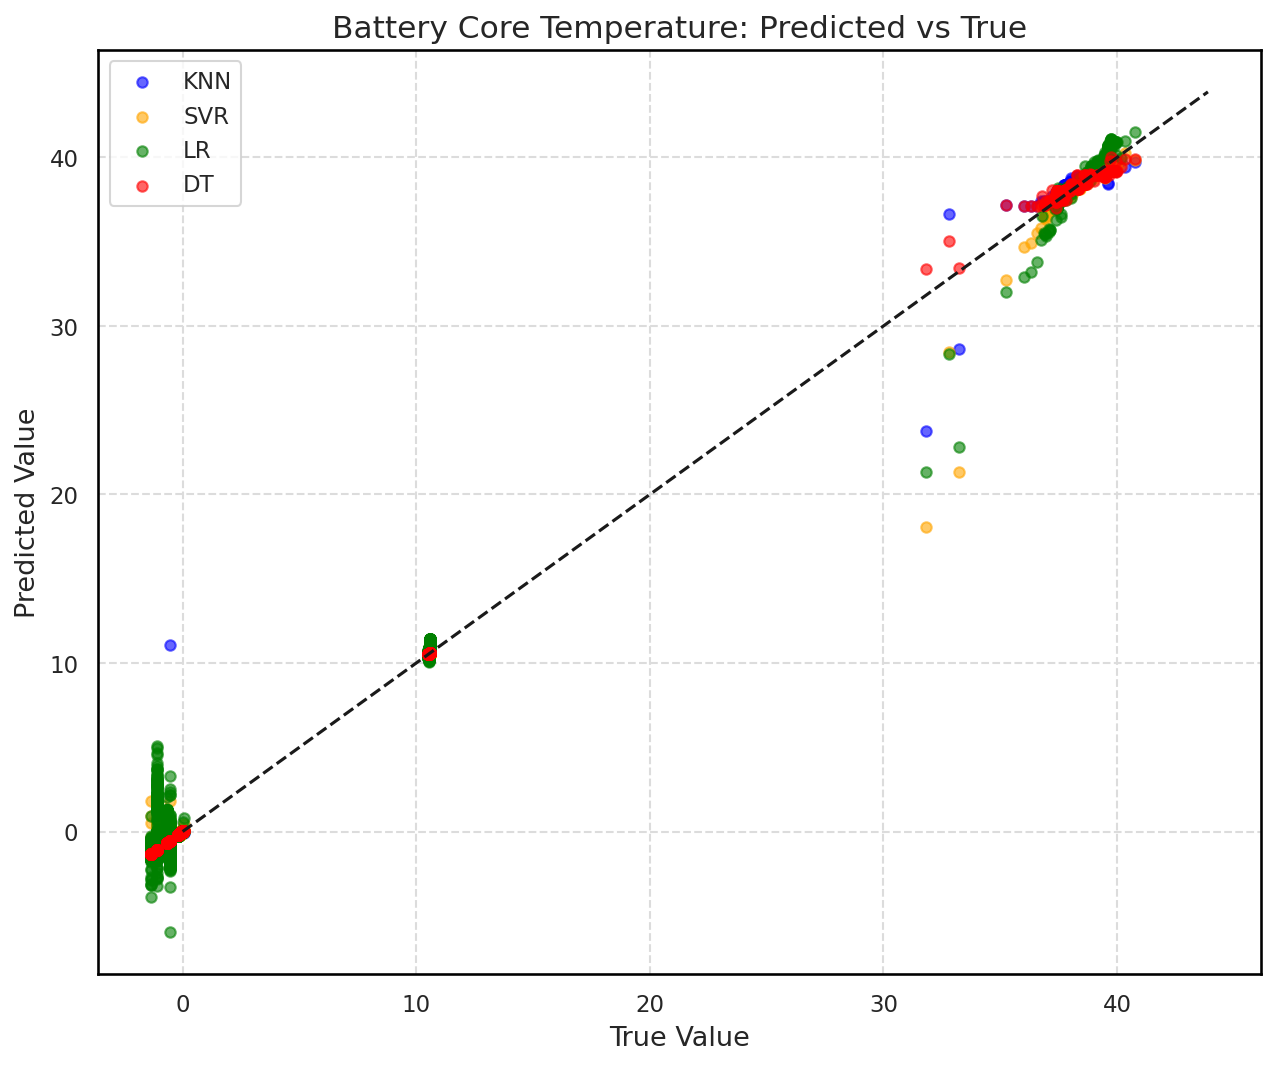

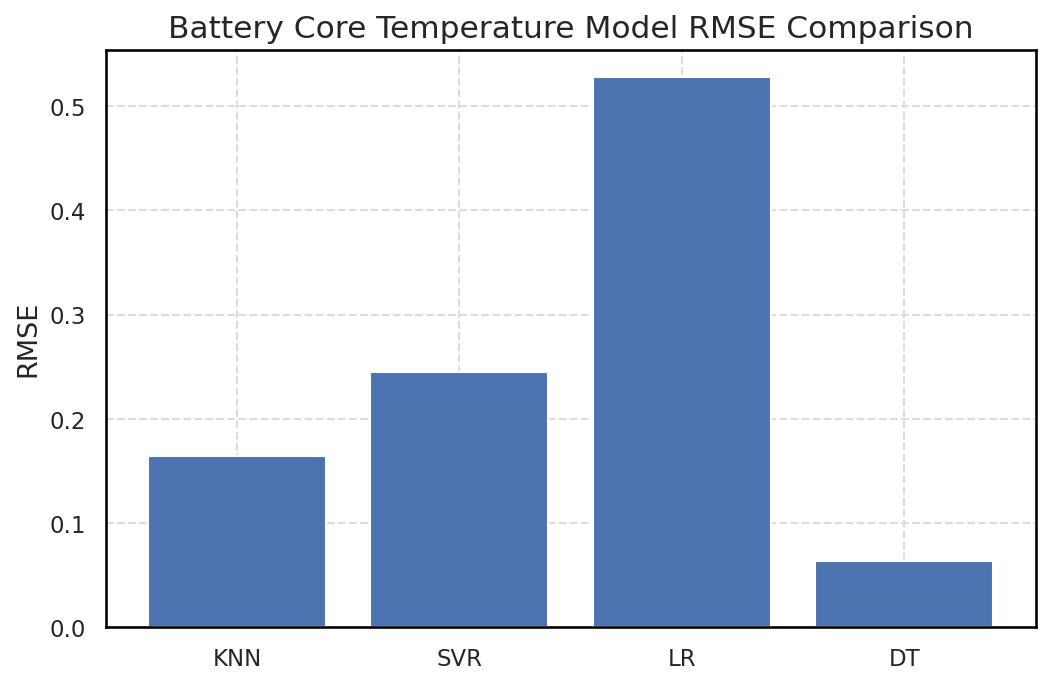

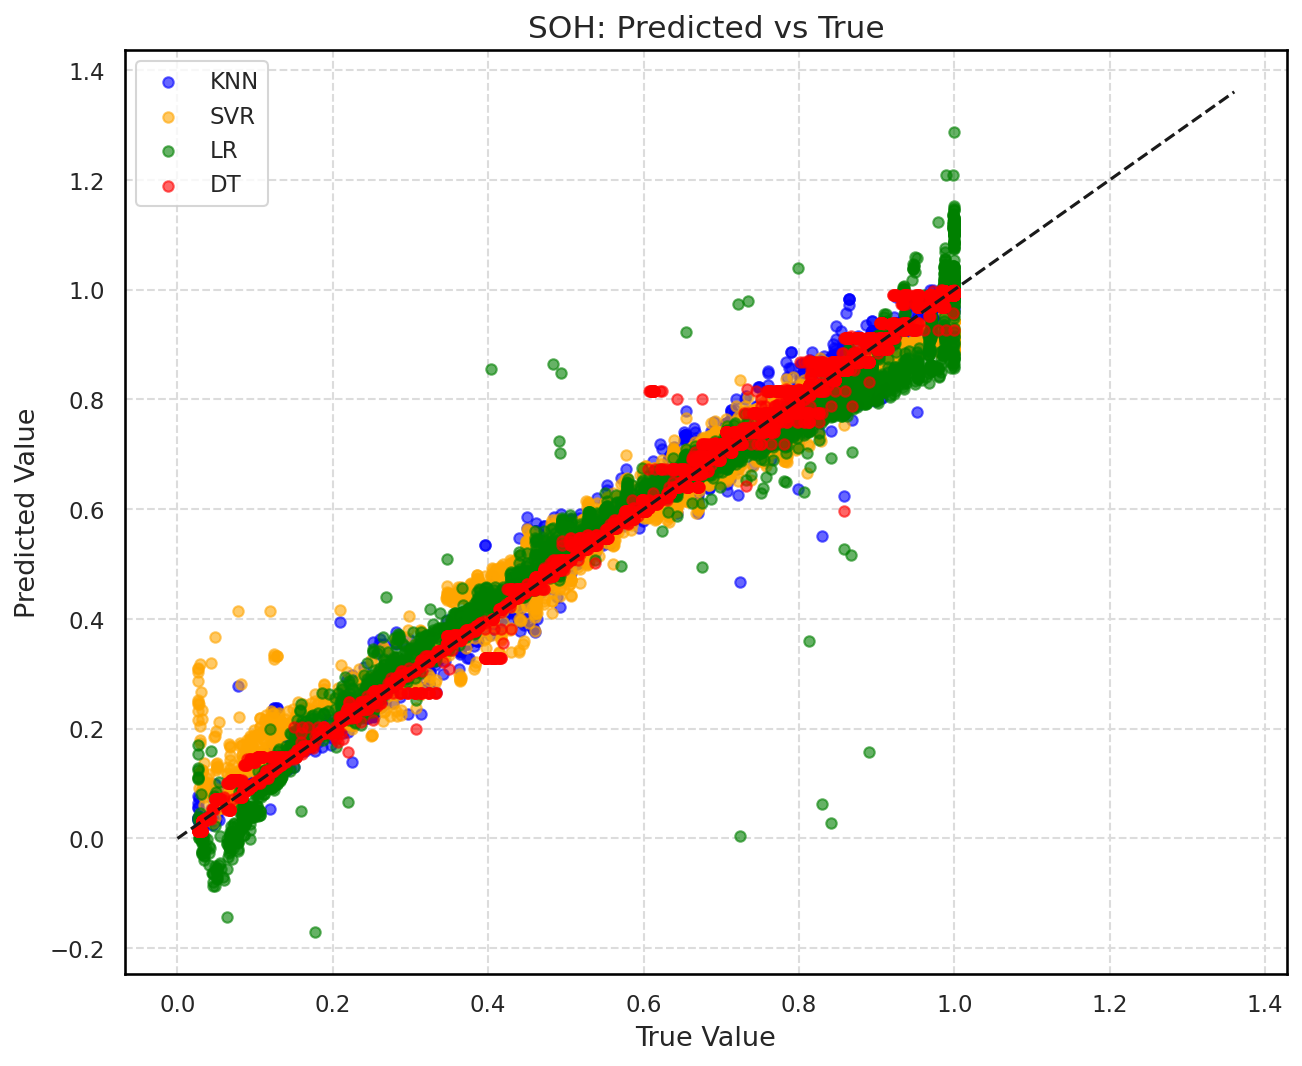

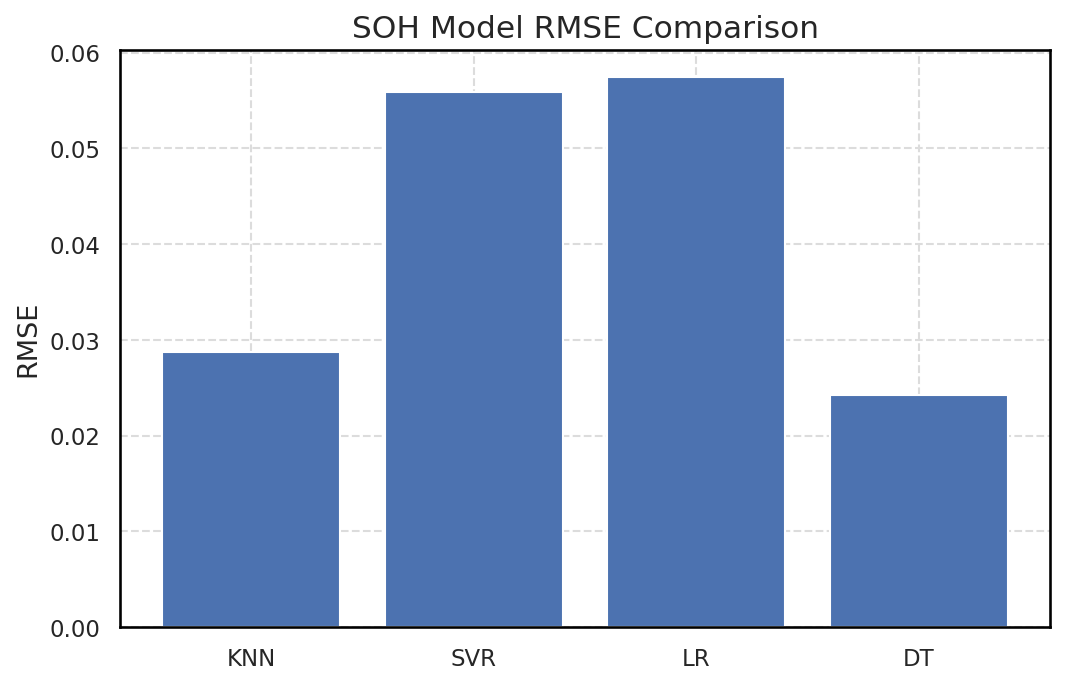

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# ------------------------------
# HD style settings
# ------------------------------
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'figure.figsize': (12, 8),
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.grid': True,
    'grid.color': '#dcdcdc',
    'grid.linestyle': '--',
    'font.size': 12,
    'legend.fontsize': 11,
    'axes.labelsize': 13,
    'axes.titlesize': 15,
})

model_colors = ['#1f77b4', '#ff7f0e', '#2ca02c','violet']
OUT_FOLDER = "figures_week5_7"
os.makedirs(OUT_FOLDER, exist_ok=True)

def generate_visuals(title, results_dict):

    import matplotlib.pyplot as plt
    import numpy as np

    model_colors = ['blue','orange','green','red','purple','brown']

    # ------------------------------
    # Predicted vs True Scatter
    # ------------------------------
    fig, ax = plt.subplots(figsize=(10,8))

    for i,(model_name,res) in enumerate(results_dict.items()):

        y_true = res['y_test']
        y_pred = res['y_preds']

        ax.scatter(
            y_true,
            y_pred,
            s=25,
            alpha=0.6,
            label=model_name.upper(),
            color=model_colors[i % len(model_colors)]
        )

    max_val = max(ax.get_xlim()[1], ax.get_ylim()[1])

    ax.plot([0,max_val],[0,max_val],'k--')

    ax.set_title(f"{title}: Predicted vs True")
    ax.set_xlabel("True Value")
    ax.set_ylabel("Predicted Value")

    ax.legend()
    plt.show()


    # ------------------------------
    # RMSE Comparison
    # ------------------------------
    fig, ax = plt.subplots(figsize=(8,5))

    model_names = []
    rmses = []

    for model_name,res in results_dict.items():

        model_names.append(model_name.upper())
        rmses.append(res['RMSE'])

    ax.bar(model_names,rmses)

    ax.set_title(f"{title} Model RMSE Comparison")
    ax.set_ylabel("RMSE")

    plt.show()

# ------------------------------
# Generate visuals for both targets
# ------------------------------
if 'core_results' in globals():
    generate_visuals('Battery Core Temperature', core_results)

if 'soh_results' in globals():
    generate_visuals('SOH', soh_results)

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

FIG_DIR = "figures_week5_7"
plt.rcParams["figure.dpi"] = 150

MODEL_LABELS = {
    "lr": "Linear Regression",
    "knn": "KNN",
    "svr": "SVR",
    "dt":"Decision Tree"
}

MODEL_COLORS = {
    "lr": "purple",
    "knn": "#2A9D8F",
    "svr": "#F4A261",
    "dt":"orange"
}

def rmse(y_true,y_pred):
    return math.sqrt(mean_squared_error(y_true,y_pred))

In [11]:
core_results_new ={"baseline":""}
core_results_new["baseline"]=core_results
core_results=core_results_new

soh_results_new ={"baseline":""}
soh_results_new["baseline"]=soh_results
soh_results=soh_results_new

## Model Performance Comparison

The `plot_metrics()` function visualizes the **performance of different machine learning models** using three key regression metrics.

### Purpose
This function creates **side-by-side bar charts** to compare model performance across:

- **RMSE (Root Mean Squared Error)** – measures the magnitude of prediction error
- **MAE (Mean Absolute Error)** – measures the average absolute difference between predicted and actual values
- **R² Score** – indicates how well the model explains variance in the target variable

### How It Works

1. **Extract Model Results**
   - The function reads results from `results_dict["baseline"]`.

2. **Collect Metrics**
   - For each model, it gathers:
     - RMSE
     - MAE
     - R² score

3. **Generate Plots**
   - Three bar charts are created:
     - RMSE comparison
     - MAE comparison
     - R² comparison

4. **Model Labels**
   - Model abbreviations are converted to readable names using `MODEL_LABELS`.

### Output

The function produces a **single figure with three subplots**, allowing quick comparison of model performance across multiple metrics.

In [16]:
def plot_metrics(results_dict, title):

    models = results_dict["baseline"]

    names=[]
    rmses=[]
    maes=[]
    r2s=[]

    for name,res in models.items():

        names.append(MODEL_LABELS.get(name,name.upper()))
        rmses.append(res["RMSE"])
        maes.append(res["MAE"])
        r2s.append(res["R2"])

    x=np.arange(len(names))

    fig,ax=plt.subplots(1,3,figsize=(16,5))

    ax[0].bar(x,rmses)
    ax[0].set_title("RMSE")

    ax[1].bar(x,maes)
    ax[1].set_title("MAE")

    ax[2].bar(x,r2s)
    ax[2].set_title("R2")

    for a in ax:
        a.set_xticks(x)
        a.set_xticklabels(names)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

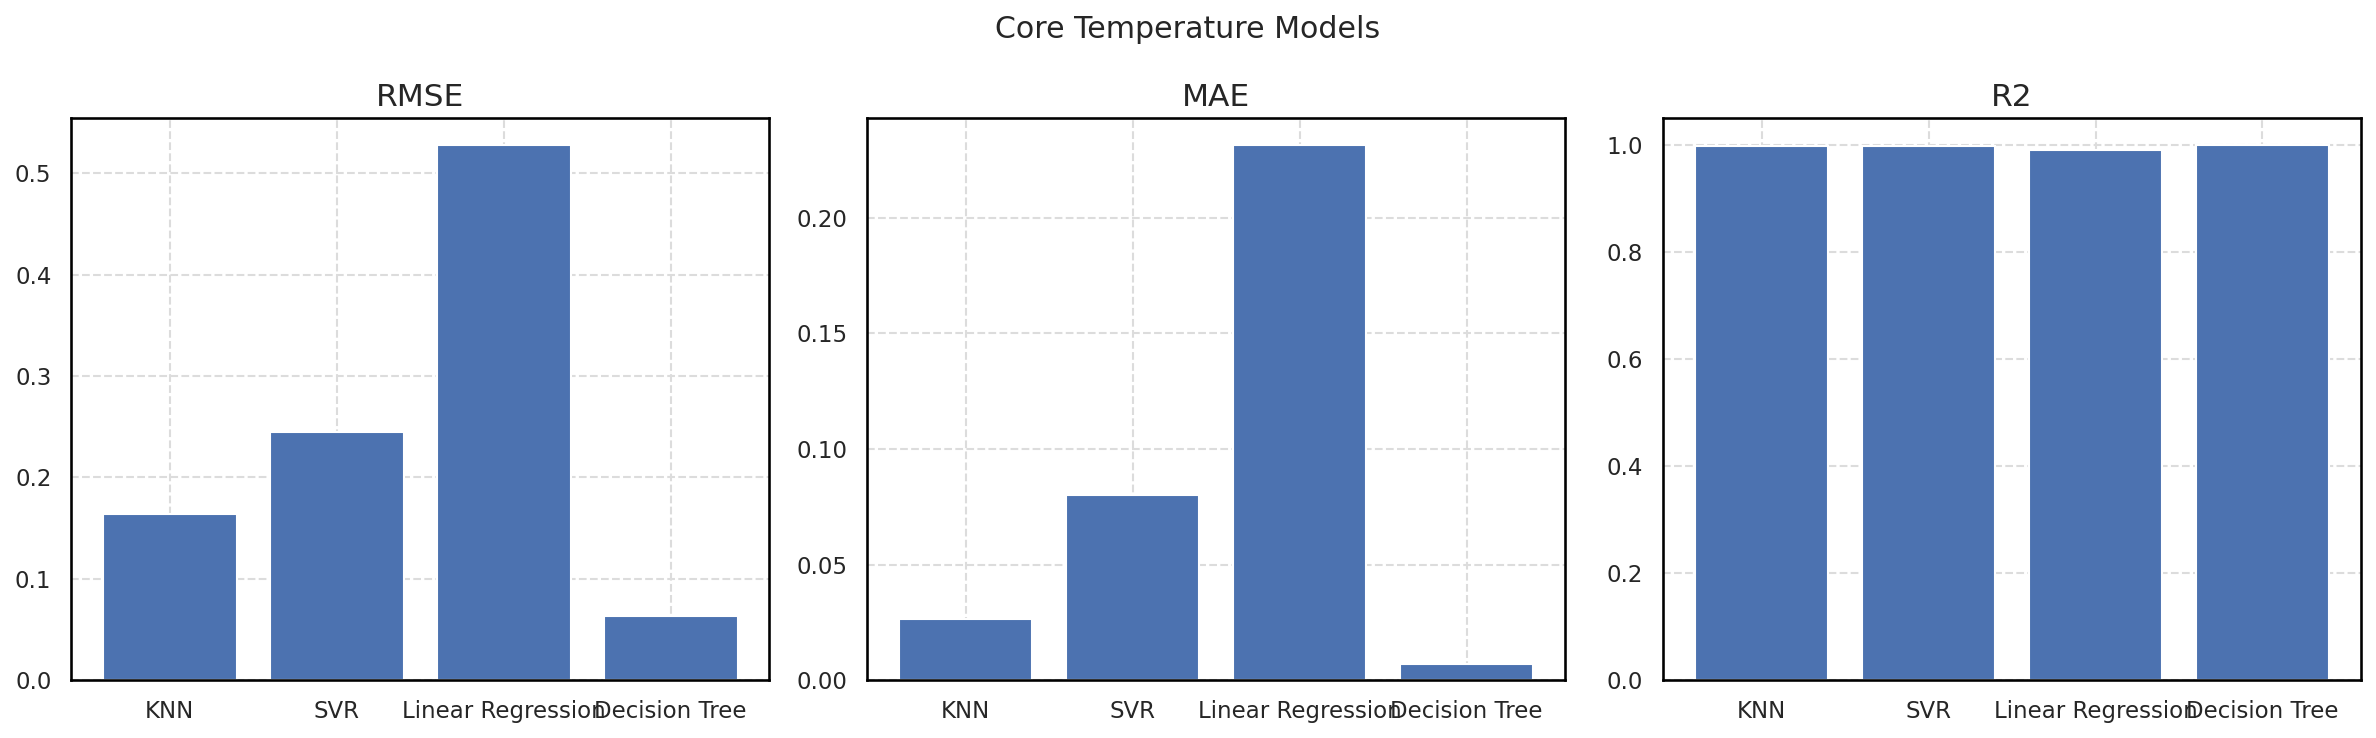

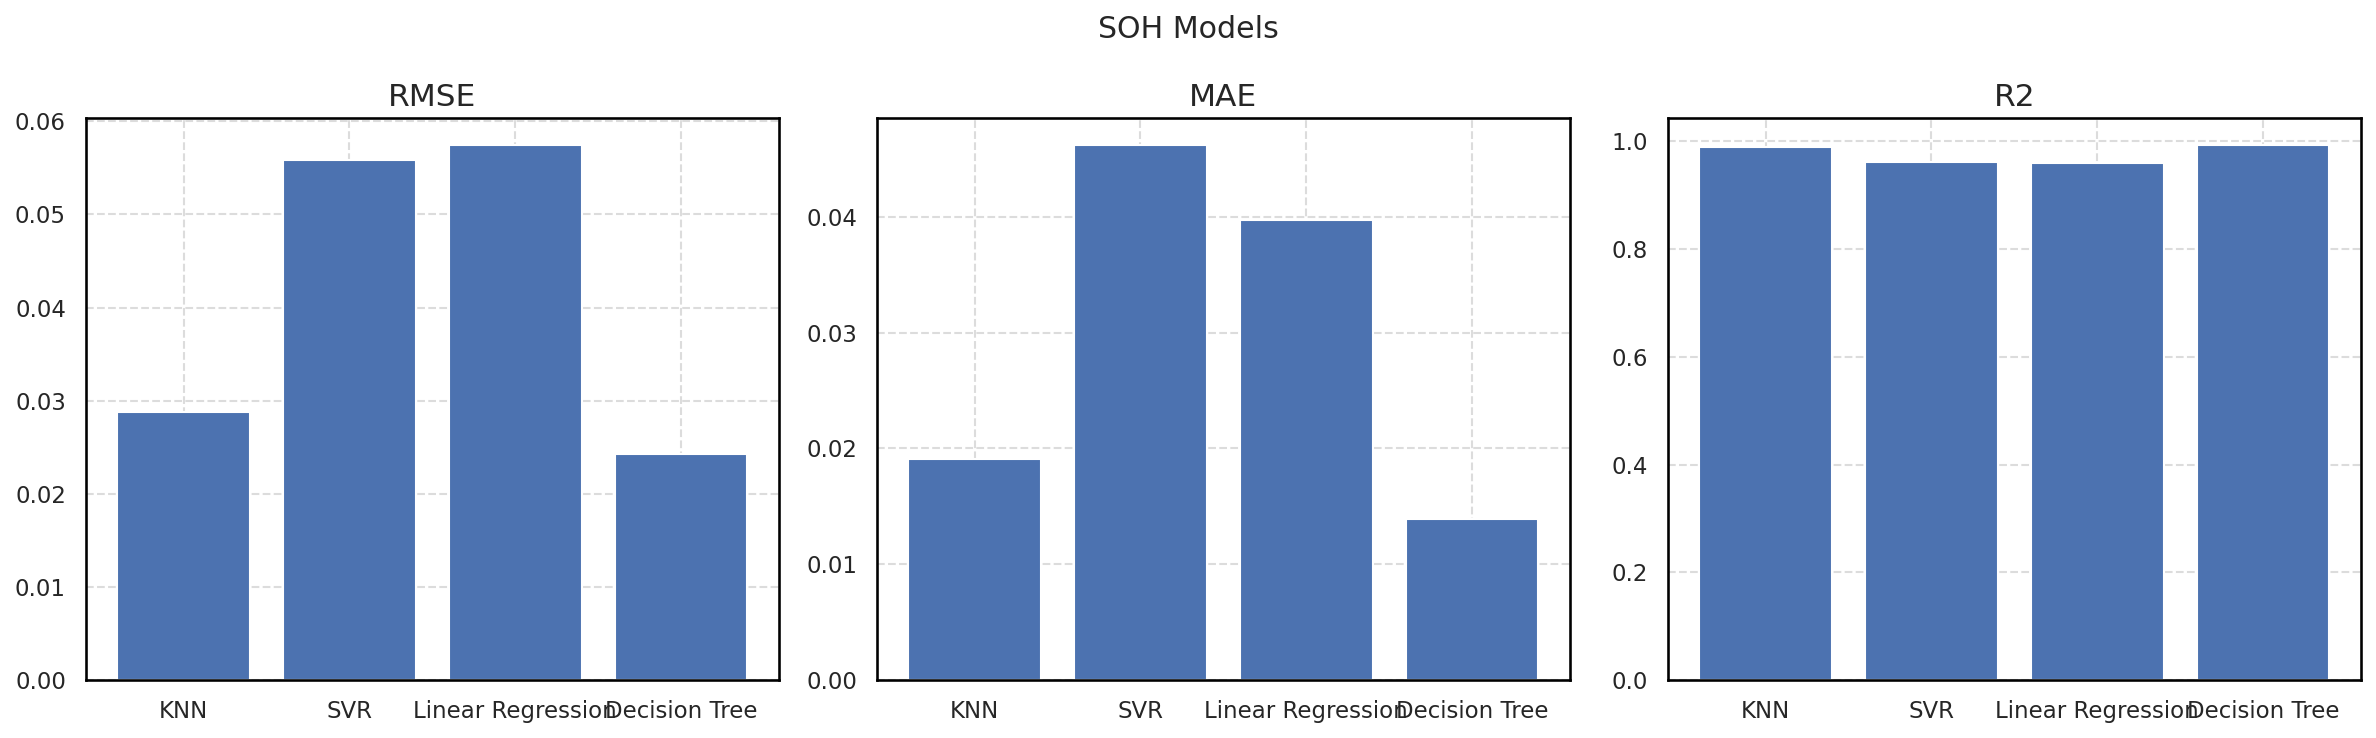

In [18]:
plot_metrics(core_results,"Core Temperature Models")
plot_metrics(soh_results,"SOH Models")

In [46]:
import numpy as np
import matplotlib.pyplot as plt

def parity_plot(results_dict, y_test_key="y_test", title="Parity Plot"):

    def clean_pair(y_test, y_pred):
        y_test = np.array(y_test).ravel()
        y_pred = np.array(y_pred).ravel()

        mask = np.isfinite(y_test) & np.isfinite(y_pred)

        y_test = y_test[mask]
        y_pred = y_pred[mask]

        n = min(len(y_test), len(y_pred))
        return y_test[:n], y_pred[:n]

    models = results_dict
    n_models = len(models)

    fig, axes = plt.subplots(1, n_models, figsize=(5*n_models,5))

    if n_models == 1:
        axes = [axes]

    for ax, (name, res) in zip(axes, models.items()):

        if "y_preds" not in res or y_test_key not in res:
            print(f"Skipping {name}: missing y_preds or y_test")
            continue

        y_pred = res["y_preds"]
        y_test = res[y_test_key]

        yt, yp = clean_pair(y_test, y_pred)

        ax.scatter(yt, yp, alpha=0.6)

        mn = min(yt.min(), yp.min())
        mx = max(yt.max(), yp.max())

        ax.plot([mn, mx], [mn, mx], 'r--')

        ax.set_xlabel("Actual")
        ax.set_ylabel("Predicted")
        ax.set_title(name.upper())

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

In [ ]:
parity_plot(core_results,"y_test","Core Temperature Parity")
parity_plot(soh_results,"y_test","SOH Parity")

In [24]:
def residual_plot(results_dict,y_test,title):

    models=results_dict["baseline"]

    plt.figure(figsize=(8,6))

    for name,res in models.items():

        y_pred=res["y_preds"]
        residual=y_test-y_pred

        sns.kdeplot(residual,label=MODEL_LABELS.get(name,name))

    plt.axvline(0,color="black",linestyle="--")
    plt.title(title)
    plt.xlabel("Residual")
    plt.legend()

    plt.show()

In [ ]:
residual_plot(core_results,"y_test","Core Temp Residuals")
residual_plot(soh_results,"y_test","SOH Residuals")

In [26]:
def feature_importance(model,features):

    importances=model.feature_importances_

    df=pd.DataFrame({
        "feature":features,
        "importance":importances
    })

    df=df.sort_values("importance",ascending=False).head(15)

    plt.figure(figsize=(8,6))

    plt.barh(df["feature"],df["importance"])

    plt.gca().invert_yaxis()

    plt.title("Feature Importance")

    plt.show()

## RMSE Comparison Between Targets

The `rmse_comparison()` function compares the **prediction performance of models across two different targets**:
- **Battery Core Temperature**
- **Battery State of Health (SOH)**

### Purpose
This function helps analyze **how well each model performs on different prediction tasks** by comparing their **RMSE values**.

### How It Works

1. **Extract RMSE Values**
   - RMSE scores are collected from:
     - `core_results["baseline"]`
     - `soh_results["baseline"]`

2. **Model Labels**
   - Model names are converted to readable labels using the `MODEL_LABELS` dictionary.

3. **Grouped Bar Chart**
   - Two bars are plotted for each model:
     - **Core Temperature RMSE**
     - **SOH RMSE**

4. **Visualization**
   - X-axis: Model names
   - Y-axis: RMSE values
   - A legend distinguishes the two prediction tasks.

### Interpretation

- **Lower RMSE** → better model performance.
- This chart allows quick comparison of **which models perform best for each prediction target**.

### Output
A **grouped bar chart** showing RMSE values for each model across both prediction tasks.

In [27]:
def rmse_comparison(core_results,soh_results):

    core_rmse=[]
    soh_rmse=[]
    labels=[]

    for name,res in core_results["baseline"].items():

        labels.append(MODEL_LABELS.get(name,name))
        core_rmse.append(res["RMSE"])
        soh_rmse.append(soh_results["baseline"][name]["RMSE"])

    x=np.arange(len(labels))

    width=0.35

    plt.figure(figsize=(8,6))

    plt.bar(x-width/2,core_rmse,width,label="Core Temp")
    plt.bar(x+width/2,soh_rmse,width,label="SOH")

    plt.xticks(x,labels)
    plt.ylabel("RMSE")
    plt.title("Model RMSE Comparison")

    plt.legend()

    plt.show()

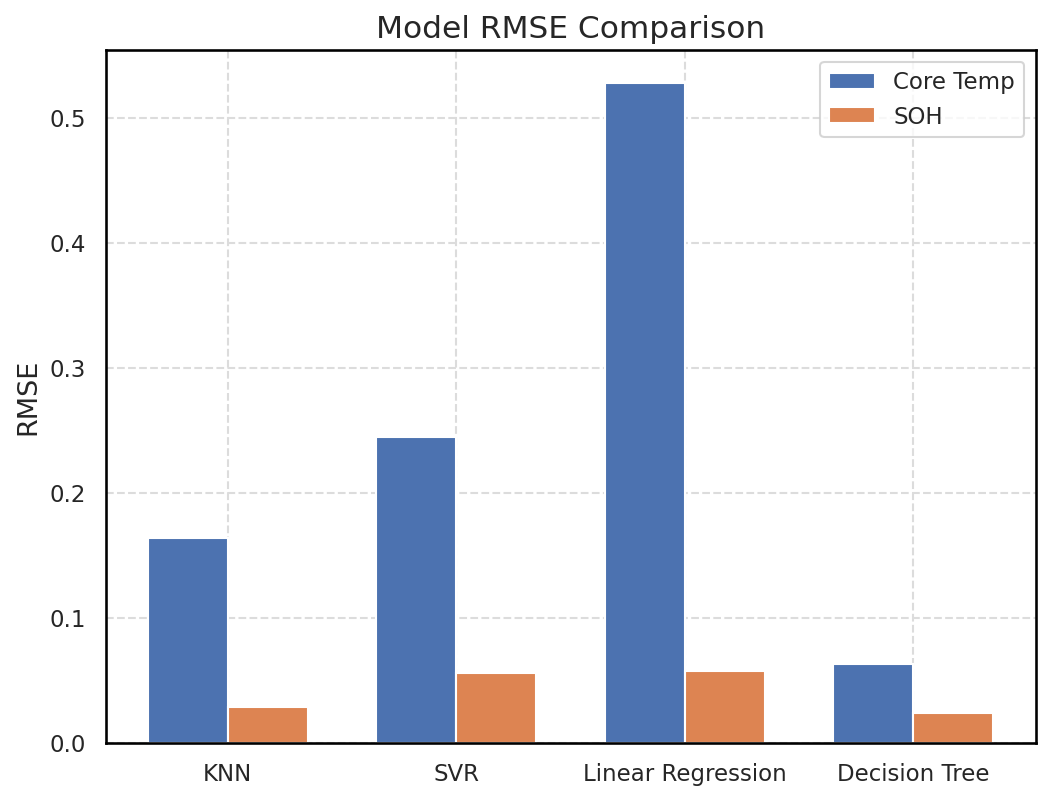

In [28]:
rmse_comparison(core_results,soh_results)

In [31]:
def scorecard(core_results,soh_results):

    rows=[]

    for name,res in core_results["baseline"].items():

        rows.append({
            "Model":MODEL_LABELS.get(name,name),
            "Task":"Core Temp",
            "RMSE":res["RMSE"],
            "MAE":res["MAE"],
            "R2":res["R2"]
        })

    for name,res in soh_results["baseline"].items():

        rows.append({
            "Model":MODEL_LABELS.get(name,name),
            "Task":"SOH",
            "RMSE":res["RMSE"],
            "MAE":res["MAE"],
            "R2":res["R2"]
        })

    df=pd.DataFrame(rows)

    display(df)

In [32]:
scorecard(core_results,soh_results)

,Model,Task,RMSE,MAE,R2
0,KNN,Core Temp,0.164418,0.026687,0.999090
1,SVR,Core Temp,0.244495,0.080308,0.997988
2,Linear Regression,Core Temp,0.527739,0.231390,0.990628
3,Decision Tree,Core Temp,0.063260,0.007124,0.999865
4,KNN,SOH,0.028756,0.019093,0.989910
5,SVR,SOH,0.055871,0.046165,0.961911
6,Linear Regression,SOH,0.057431,0.039707,0.959754
7,Decision Tree,SOH,0.024277,0.013940,0.992809
